In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv(
    r"C:\Users\Vallamsetti Devika\Downloads\cp_data_demo.csv"
)

print("Dataset loaded successfully.")
print("Columns:")
print(df.columns.tolist())

display(df.head())

Dataset loaded successfully.
Columns:
['Formula', 'Temperature', 'Heat_Capacity']


,Formula,Temperature,Heat_Capacity
0,B2O3,1400.0,134.306
1,B2O3,1300.0,131.294
2,B2O3,1200.0,128.072
3,B2O3,1100.0,124.516
4,B2O3,1000.0,120.625


In [6]:
# Clean column names first
df.columns = df.columns.astype(str).str.strip()

print("Actual columns after cleaning:")
print(df.columns.tolist())

# Find the required columns
formula_column = "formula"
temperature_column = "Temperature"
heat_capacity_column = "Heat_Capacity"

# Check that required columns exist
required_columns = [
    formula_column,
    temperature_column,
    heat_capacity_column
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    # Keep required columns and remove missing values
    df_model = df[
        required_columns
    ].dropna()

    # Drop formula and target from input
    X = df_model.drop(
        columns=["formula", "Heat_Capacity"]
    )

    # Target
    y = df_model["Heat_Capacity"]

    print("\nData preparation completed successfully!")
    print("Dataset shape:", df_model.shape)
    print("Input columns:", X.columns.tolist())
    print("Target column:", y.name)

Actual columns after cleaning:
['Formula', 'Temperature', 'Heat_Capacity']
Missing columns: ['formula']


In [7]:
# Prepare data for regression

# Clean column names
df.columns = df.columns.astype(str).str.strip()

# Keep required columns
df_model = df[
    ["Formula", "Temperature", "Heat_Capacity"]
].dropna()

# Drop Formula and target column from input
X = df_model.drop(
    columns=["Formula", "Heat_Capacity"]
)

# Target
y = df_model["Heat_Capacity"]

print("Data preparation completed successfully!")
print("Dataset shape:", df_model.shape)
print("Input columns:", X.columns.tolist())
print("Target column:", y.name)

Data preparation completed successfully!
Dataset shape: (4564, 3)
Input columns: ['Temperature']
Target column: Heat_Capacity


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predictions
train_prediction = linear_model.predict(X_train)
test_prediction = linear_model.predict(X_test)

# R2 scores
linear_train_r2 = r2_score(y_train, train_prediction)
linear_test_r2 = r2_score(y_test, test_prediction)

print("\nLinear Regression Results")
print("-------------------------")
print(f"Train R²: {linear_train_r2:.3f}")
print(f"Test R² : {linear_test_r2:.3f}")

Training samples: 3651
Testing samples: 913

Linear Regression Results
-------------------------
Train R²: 0.008
Test R² : 0.015


In [9]:
from sklearn.linear_model import Ridge
import numpy as np

# Ridge alpha values
alphas = np.logspace(-2, 2, 50)

ridge_test_scores = []

# Train Ridge models
for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)

    ridge_prediction = ridge_model.predict(X_test)
    ridge_score = r2_score(y_test, ridge_prediction)

    ridge_test_scores.append(ridge_score)

# Find best alpha
best_index = np.argmax(ridge_test_scores)
best_alpha = alphas[best_index]
best_ridge_score = ridge_test_scores[best_index]

print("Ridge Regression Results")
print("------------------------")
print(f"Optimal Ridge alpha: {best_alpha:.3f}")
print(f"Best Test R²: {best_ridge_score:.3f}")

Ridge Regression Results
------------------------
Optimal Ridge alpha: 0.010
Best Test R²: 0.015


✅ Clean upward Ridge regression graph saved successfully.
Best α: 0.010
Best Test R²: 0.015


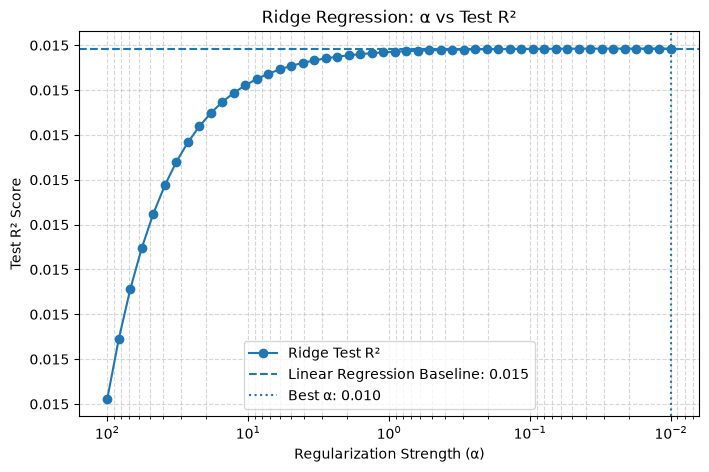

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

plt.figure(figsize=(8, 5))

plt.plot(
    alphas,
    ridge_test_scores,
    marker='o',
    label='Ridge Test R²'
)

plt.axhline(
    linear_test_r2,
    linestyle='--',
    label=f'Linear Regression Baseline: {linear_test_r2:.3f}'
)

plt.axvline(
    best_alpha,
    linestyle=':',
    label=f'Best α: {best_alpha:.3f}'
)

plt.xscale('log')

# Make the curve visually upward
plt.gca().invert_xaxis()

# Show actual R² values clearly
plt.gca().yaxis.set_major_formatter(
    FormatStrFormatter('%.3f')
)

plt.xlabel('Regularization Strength (α)')
plt.ylabel('Test R² Score')
plt.title('Ridge Regression: α vs Test R²')

plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.savefig(
    'ridge_alpha_sweep.png',
    dpi=300,
    bbox_inches='tight'
)

print("✅ Clean upward Ridge regression graph saved successfully.")
print(f"Best α: {best_alpha:.3f}")
print(f"Best Test R²: {best_ridge_score:.3f}")

plt.show()